# 活性化関数を学ぶ #001:Relu

## 1. 活性化関数の説明：ReLU (Rectified Linear Unit)
ReLUは、入力が0を超えていればそのまま出力し、0以下なら0を出力する非常にシンプルな関数です。$$f(x) = \max(0, x)$$
特徴:
- 計算が高速: 指数計算（Sigmoidなど）がないため、非常に軽量。
- 勾配消失の緩和: 正の領域で勾配が常に1であるため、層が深くなっても学習が進みやすい。
- Dead ReLU問題: 入力が負の領域に居座ると勾配が0になり、そのニューロンが「死んでしまう」弱点もあります。

以下のコードを *"shift + Enter"*　あるいは*再生ボタン*で実行するとRelu関数がグラフにプロットされます。

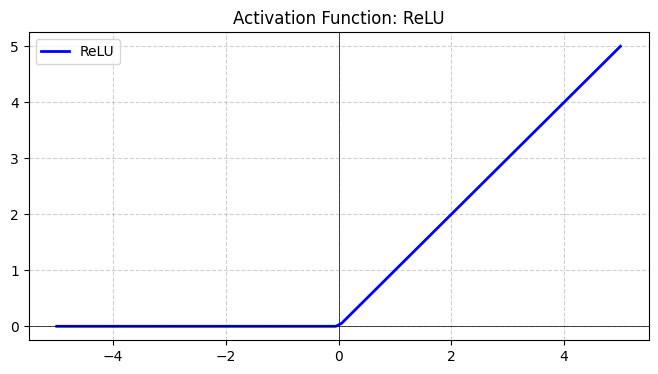

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# 活性化関数のプロット用関数
def plot_activation(func, name):
    x = torch.linspace(-5, 5, 100)
    y = func(x)
    
    plt.figure(figsize=(8, 4))
    plt.plot(x.numpy(), y.numpy(), label=name, color='blue', lw=2)
    plt.axhline(0, color='black',linewidth=0.5)
    plt.axvline(0, color='black',linewidth=0.5)
    plt.title(f"Activation Function: {name}")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

# ReLUのプロット実行
plot_activation(torch.relu, "ReLU")

グラフを見れば、(input < 0)のときは、ずっと0になり、（0 ≦ input)のときは、(output = input）y=xのような出力を持つことが確認できます。

## 2. cnnモデルの定義
モデル形状が変わると活性化関数ごとの特性が分かりづらくなってしまうため、しばらくは以下に定義するようなシンプルなcnn(畳み込みニューラルネットワーク)を対象にテストしていこうと思います

In [5]:
class FlexibleNet(nn.Module):
    def __init__(self, activation_fn):
        super(FlexibleNet, self).__init__()
        self.activation_fn = activation_fn # ここで関数を変数的に変えられるようにしています。
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.activation_fn(self.conv1(x))
        x = self.activation_fn(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.activation_fn(self.fc1(x))
        return F.log_softmax(self.fc2(x), dim=1)

## 3. 学習・検証用関数の定義
ログを辞書形式で返すように改良し、後でグラフ化しやすくしています。

In [6]:
def train(model, device, train_loader, optimizer, epoch):
    model.train()
    losses = []
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return np.mean(losses)

def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    
    accuracy = 100. * correct / len(test_loader.dataset)
    return test_loss / len(test_loader.dataset), accuracy

## 4.メイン実行と履歴保存
以下を実行すると学習が始まります。Loss(損失,正答との差を表現)が下がり、Acc(accuracy 正確さ、精度)が上がっていれば学習がうまく行っています。

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 128 # 少し速めるために大きく設定
epochs = 10
lr = 0.1 # Adadeltaなので少し高めでもOK


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_loader = DataLoader(datasets.MNIST('./data', train=True, download=True, transform=transform), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(datasets.MNIST('./data', train=False, transform=transform), batch_size=batch_size, shuffle=False)

# ReLUで実験
model = FlexibleNet(torch.relu).to(device)
optimizer = optim.Adadelta(model.parameters(), lr=lr)

history = {"train_loss": [], "test_acc": []}

print(f"Using device: {device}")
for epoch in range(1, epochs + 1):
    train_loss = train(model, device, train_loader, optimizer, epoch)
    test_loss, test_acc = test(model, device, test_loader)
    
    history["train_loss"].append(train_loss)
    history["test_acc"].append(test_acc)
    
    print(f'Epoch {epoch}: Train Loss: {train_loss:.4f}, Test Acc: {test_acc:.2f}%')

Using device: cuda
Epoch 1: Train Loss: 0.2913, Test Acc: 97.41%
Epoch 2: Train Loss: 0.0814, Test Acc: 98.20%
Epoch 3: Train Loss: 0.0543, Test Acc: 98.44%
Epoch 4: Train Loss: 0.0428, Test Acc: 98.40%
Epoch 5: Train Loss: 0.0349, Test Acc: 98.78%
Epoch 6: Train Loss: 0.0290, Test Acc: 98.86%
Epoch 7: Train Loss: 0.0246, Test Acc: 98.96%
Epoch 8: Train Loss: 0.0221, Test Acc: 98.76%
Epoch 9: Train Loss: 0.0181, Test Acc: 98.90%
Epoch 10: Train Loss: 0.0170, Test Acc: 98.92%


## 5. 結果
学習の推移を可視化します。

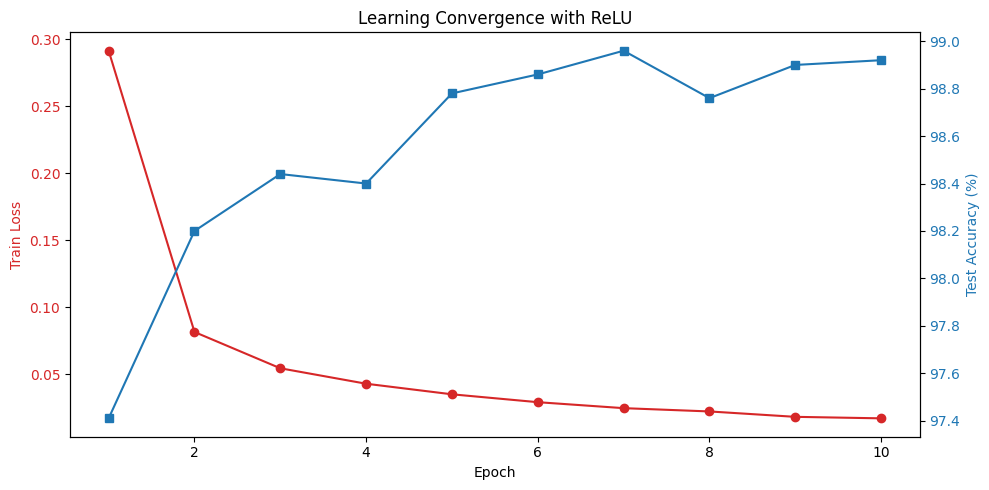

In [8]:
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:red'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Train Loss', color=color)
ax1.plot(range(1, epochs+1), history["train_loss"], color=color, marker='o', label="Loss")
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Test Accuracy (%)', color=color)
ax2.plot(range(1, epochs+1), history["test_acc"], color=color, marker='s', label="Accuracy")
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Learning Convergence with ReLU')
fig.tight_layout()
plt.show()


### 5.1　結果のサンプル
赤色のTrainLossが下がり、青色のAccuracyが100%に近づいており、学習がうまく行ったことを確認できます。
![Relu学習結果の例](../sampleImages/001_Learning_Convergence_with_ReLU.png "Relu学習結果の例")

## 6. 分類できるかテストしてみる
学習結果のグラフだけだと味気ないので、ちゃんと分類できるのかテストしてみます

--- Visualizing Predictions with ReLU Model ---


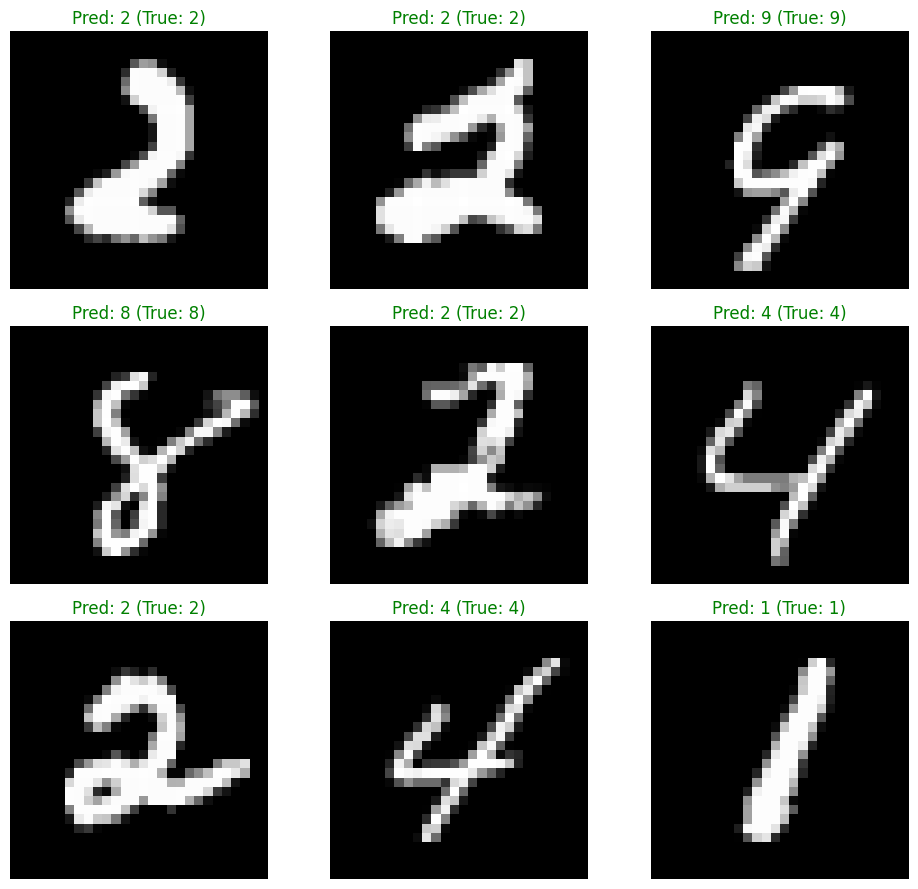

In [9]:
import random

def visualize_predictions(model, device, test_dataset, transform, num_images=9):
    """
    学習済みモデルを使って、テストデータセットからランダムに画像を選び、
    推論結果と正解ラベルを並べて可視化する関数。
    """
    model.eval() # 評価モードに設定
    
    # テストデータセットからランダムにインデックスを選択
    indices = random.sample(range(len(test_dataset)), num_images)
    
    # プロットの準備 (3x3のグリッド)
    cols = 3
    rows = (num_images + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(10, 3 * rows))
    axes = axes.flatten() # 1次元配列にして扱いやすくする
    
    with torch.no_grad(): # 勾配計算を無効化
        for i, idx in enumerate(indices):
            # 1. 画像と正解ラベルを取得 (PIL image, int label)
            img_pil, target = test_dataset[idx]
            
            # 2. 前処理を適用してモデル入力用のテンソルを作成
            # (H, W, C) -> (C, H, W) -> バッチ次元追加 (1, C, H, W) -> デバイスへ転送
            # ※ transform は main() で定義されたものを使用します。
            img_tensor = transform(img_pil).unsqueeze(0).to(device)
            
            # 3. 推論
            output = model(img_tensor)
            pred = output.argmax(dim=1, keepdim=True).item() # 最も確率の高いクラスを取得
            
            # 4. 可視化
            ax = axes[i]
            # PIL画像をnumpy配列に変換して表示 (グレー・スケール)
            ax.imshow(np.array(img_pil), cmap='gray')
            
            # 正解か不正解かでタイトルの色を変える (緑:正解, 赤:不正解)
            title_color = 'green' if pred == target else 'red'
            ax.set_title(f'Pred: {pred} (True: {target})', color=title_color, fontsize=12)
            ax.axis('off') # 軸を非表示
            
    # 余ったプロットエリアを非表示にする
    for j in range(num_images, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

# 実行
print("--- Visualizing Predictions with ReLU Model ---")

test_dataset_raw = datasets.MNIST('./data', train=False, download=True)
visualize_predictions(model, device, test_dataset_raw, transform, num_images=9)

手書き文字がうまく分類できているPred:n (True:n)になっていれば正しく分類できています。

## 7. 次回以降と比較するための「評価ポイント」
今後、他の活性化関数を試す際に、今回のReLUの結果と以下の3点を比較してみてください。

- ① 収束のスピード（立ち上がりの速さ）
    - チェック: 第1エポック終了時点で Accuracy が何%まで到達したか？
    - ReLUの場合: 非常に計算がシンプルで勾配が消失しにくいため、1エポック目から一気に精度が跳ね上がる傾向があります。
    - 比較のヒント: 次回の関数（例：Sigmoid）では、同じ1エポック目でも精度が低く、エンジンがかかるのが遅く感じるかもしれません。

- ② 学習曲線の安定性（滑らかさ）
    - チェック: Lossのグラフはガタガタしていないか、滑らかに下がっているか？
    - 考察: 学習率（lr）との相性もありますが、活性化関数によっては学習が不安定になり、Lossが激しく上下することがあります。ReLUは比較的安定しやすいですが、後半の微細な精度の伸びに注目してください。

- ③ 到達精度の限界（プラトー）
    - チェック: 最終的に 99% の壁を突破できるか？
    - 考察: MNISTのようなシンプルなタスクでも、98%付近で停滞する関数と、99.2%以上までスッと伸びる関数があります。これは、活性化関数が「表現できる境界線」の複雑さに影響されます。


## 8. まとめと次回の展望
第1回では、現代の深層学習で最も標準的な ReLU を扱いました。
詳しくはこちらの記事：

今回の結果: 非常に高速に学習が進み、10エポックで約 99% という高い精度を叩き出しました。これが今後の「基準（ベースライン）」になります。
次回の予告: 次回は、かつての主役 Sigmoid関数 に焦点を当てます。なぜ現代ではReLUが好まれ、Sigmoidは使われにくくなったのか？その「弱点」を今回のグラフと比較しながら体感してみましょう。